In [4]:
import kagglehub, os

path = kagglehub.dataset_download("belalsafy/egyptian-new-currency-2023")
print("Path to dataset files:", path)

for root, dirs, files_ in os.walk(path):
    depth = root[len(path):].count(os.sep)
    if depth <= 2:
        print(f"Root: {root} | Directories: {dirs[:10]} | File Count: {len(files_)}")

100%|██████████| 395M/395M [00:02<00:00, 149MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/belalsafy/egyptian-new-currency-2023/versions/1
/root/.cache/kagglehub/datasets/belalsafy/egyptian-new-currency-2023/versions/1 | مجلدات: ['dataset'] | عدد الملفات: 0
/root/.cache/kagglehub/datasets/belalsafy/egyptian-new-currency-2023/versions/1/dataset | مجلدات: ['train', 'valid', 'test'] | عدد الملفات: 0
/root/.cache/kagglehub/datasets/belalsafy/egyptian-new-currency-2023/versions/1/dataset/train | مجلدات: ['200', '100', '20 (new)', '10', '5', '50', '1', '20', '10 (new)'] | عدد الملفات: 0
/root/.cache/kagglehub/datasets/belalsafy/egyptian-new-currency-2023/versions/1/dataset/valid | مجلدات: ['200', '100', '20 (new)', '10', '5', '50', '1', '20', '10 (new)'] | عدد الملفات: 0
/root/.cache/kagglehub/datasets/belalsafy/egyptian-new-currency-2023/versions/1/dataset/test | مجلدات: ['200', '100', '20 (new)', '10', '5', '50', '1', '20', '10 (new)'] | عدد الملفات: 0


In [5]:
import os
DATA_DIR = os.path.join(path, "dataset")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "valid")
TEST_DIR  = os.path.join(DATA_DIR, "test")
IMG_SIZE = (224, 224)
BATCH = 32

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, seed=42, image_size=IMG_SIZE, batch_size=BATCH)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, shuffle=False, image_size=IMG_SIZE, batch_size=BATCH)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, shuffle=False, image_size=IMG_SIZE, batch_size=BATCH)

class_names = train_ds.class_names
print("class:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

augment = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base.trainable = False

model = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    augment,
    layers.Rescaling(1./127.5, offset=-1),
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax"),
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.fit(train_ds, validation_data=val_ds, epochs=10)

loss, acc = model.evaluate(test_ds)
# Print the evaluation test accuracy formatted as a percentage
print(f"Test Accuracy: {acc*100:.1f}%")

Found 2637 files belonging to 9 classes.
Found 760 files belonging to 9 classes.
Found 290 files belonging to 9 classes.
الفئات: ['1', '10', '10 (new)', '100', '20', '20 (new)', '200', '5', '50']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 32s 276ms/step - accuracy: 0.3349 - loss: 1.8755 - val_accuracy: 0.5289 - val_loss: 1.2927
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 23s 270ms/step - accuracy: 0.5882 - loss: 1.1753 - val_accuracy: 0.6605 - val_loss: 0.9972
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 40s 259ms/step - accuracy: 0.6780 - loss: 0.9339 - val_accuracy: 0.7184 - val_loss: 0.8580
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 262ms/step - accuracy: 0.7186 - loss: 0.8023 - val_accuracy: 0.7447 - val_loss: 0.7733
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 40s 257ms/step - accuracy: 0.7512 - loss: 0.7250 - val_accuracy: 0.7566 - val_loss: 0.6936
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 261ms/step - accuracy: 0.7744 - loss: 0.6757 - val_accuracy: 0.7895 

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_currency(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    arr = np.expand_dims(image.img_to_array(img), axis=0)

    probs = model.predict(arr, verbose=0)[0]
    idx = int(np.argmax(probs))

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Value: {class_names[idx]}  |  Confidence: {probs[idx]*100:.1f}%")
    plt.show()

    # Top 3 probabilities
    for i in np.argsort(probs)[::-1][:3]:
        print(f"{class_names[i]}: {probs[i]*100:.1f}%")

    return class_names[idx]

Saving WhatsApp Image 2026-10-05 at 12.25.55 AM.jpeg to WhatsApp Image 2026-10-05 at 12.25.55 AM (2).jpeg


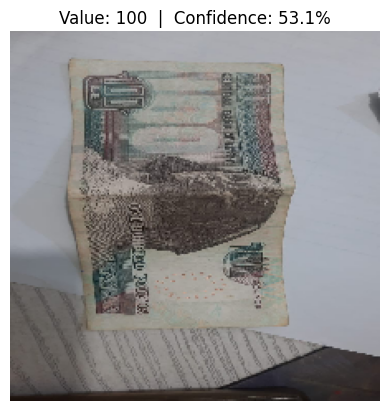

100: 53.1%
50: 36.3%
20: 6.6%


'100'

In [11]:
from google.colab import files
up = files.upload()
predict_currency(list(up.keys())[0])

Saving WhatsApp Image 2026-10-05 at 5.54.01 PM.jpeg to WhatsApp Image 2026-10-05 at 5.54.01 PM.jpeg


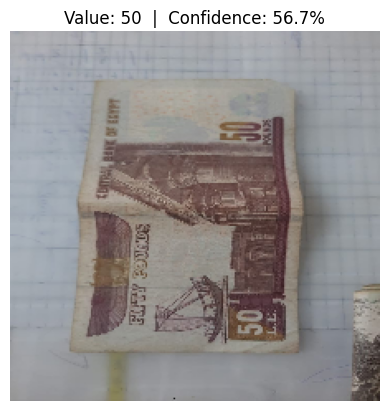

50: 56.7%
5: 16.3%
20: 12.2%


'50'

In [14]:
from google.colab import files
up = files.upload()
predict_currency(list(up.keys())[0])